100%|██████████| 170M/170M [00:03<00:00, 43.4MB/s]


Using device: cuda

Training with λ = 0.7
  [λ=0.7] Epoch 5/20  loss=1496.63  λ_eff=0.4667  sparsity=0.3%
  [λ=0.7] Epoch 10/20  loss=1477.19  λ_eff=0.7000  sparsity=1.3%
  [λ=0.7] Epoch 15/20  loss=1315.32  λ_eff=0.7000  sparsity=3.5%
  [λ=0.7] Epoch 20/20  loss=1217.39  λ_eff=0.7000  sparsity=6.0%
  → Accuracy: 57.54%  |  Sparsity: 6.01%

Training with λ = 1.5
  [λ=1.5] Epoch 5/20  loss=1891.20  λ_eff=1.0000  sparsity=0.9%
  [λ=1.5] Epoch 10/20  loss=1911.74  λ_eff=1.5000  sparsity=14.3%
  [λ=1.5] Epoch 15/20  loss=1644.18  λ_eff=1.5000  sparsity=25.1%
  [λ=1.5] Epoch 20/20  loss=1510.30  λ_eff=1.5000  sparsity=28.9%
  → Accuracy: 57.21%  |  Sparsity: 28.91%

Training with λ = 2.3
  [λ=2.3] Epoch 5/20  loss=2259.75  λ_eff=1.5333  sparsity=2.3%
  [λ=2.3] Epoch 10/20  loss=2151.94  λ_eff=2.3000  sparsity=31.5%
  [λ=2.3] Epoch 15/20  loss=1812.74  λ_eff=2.3000  sparsity=41.6%
  [λ=2.3] Epoch 20/20  loss=1665.25  λ_eff=2.3000  sparsity=45.3%
  → Accuracy: 57.44%  |  Sparsity: 45.28%

Tra

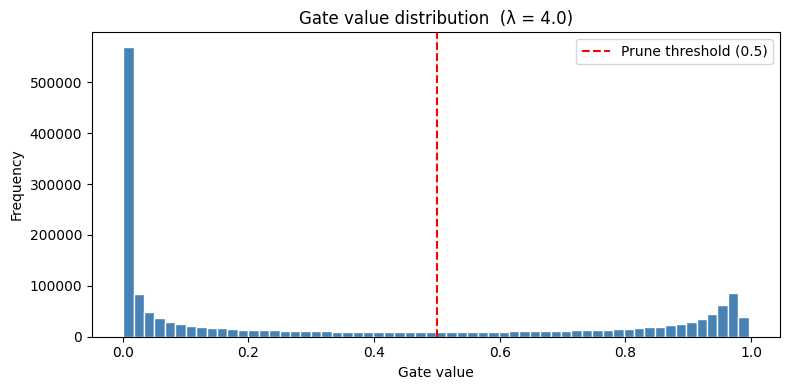

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


# ----------------------------
# PrunableLinear
# ----------------------------
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias   = nn.Parameter(torch.zeros(out_features))

        # CHANGE 1: Init gate_scores to 1.0 (was 0.5).
        # sigmoid(1.0 * 4) ≈ 0.98 — gates start almost fully open.
        # This gives the task loss time to shape weights before any pruning bites.
        self.gate_scores = nn.Parameter(torch.ones(out_features, in_features))

        # CHANGE 2: Temperature lowered to 4 (was 5/10).
        # Wider sigmoid gradient window (±1.2) — gates can recover if pruned too early.
        self.temperature = 4.0

    def forward(self, x):
        gates         = torch.sigmoid(self.gate_scores * self.temperature)
        pruned_weight = self.weight * gates
        return F.linear(x, pruned_weight, self.bias)


# ----------------------------
# Model
# ----------------------------
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1     = PrunableLinear(3072, 512)
        self.fc2     = PrunableLinear(512, 256)
        self.fc3     = PrunableLinear(256, 10)
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.fc3(x)
        return x


# ----------------------------
# Dataset
# ----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)


# ----------------------------
# Sparsity loss
# ----------------------------
def get_sparsity_loss(model):
    """
    CHANGE 3: Use mean(gates) directly — no sqrt.

    The sqrt (concave) penalty was too aggressive: it gives extremely large
    gradients near 0, which can permanently kill gates that are still useful.
    A plain mean is simpler, more stable, and easier to balance with lambda.

    To control the shape of pruning, we rely on lambda warmup + gate LR instead.
    """
    total = 0.0
    count = 0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates  = torch.sigmoid(module.gate_scores * module.temperature)
            total += gates.sum()
            count += gates.numel()
    return total / max(count, 1)


# ----------------------------
# Lambda warmup
# ----------------------------
def get_lambda(epoch, lambda_target, warmup_epochs=6):
    """
    CHANGE 4: Warmup extended to 6 epochs (was 4).
    Longer warmup gives the model more time to establish useful weights
    before sparsity pressure kicks in — avoids early collapse.
    """
    if epoch < warmup_epochs:
        return lambda_target * (epoch / warmup_epochs)
    return lambda_target


# ----------------------------
# Sparsity calculation
# ----------------------------
def calculate_sparsity(model, threshold=0.5):
    total  = 0
    pruned = 0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates   = torch.sigmoid(module.gate_scores * module.temperature)
            total  += gates.numel()
            pruned += (gates < threshold).sum().item()
    return 100 * pruned / total


# ----------------------------
# Evaluation
# ----------------------------
def evaluate(model, device):
    model.eval()
    correct = 0
    total   = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            _, predicted   = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total


# ----------------------------
# Training
# ----------------------------
def train_model(lambda_sparse, device, epochs=20):
    model = PrunableNet().to(device)

    weight_params = [p for n, p in model.named_parameters() if 'gate' not in n]
    gate_params   = [p for n, p in model.named_parameters() if 'gate' in n]

    # CHANGE 5: Weight decay of 1e-4 on weight params only.
    # Mild L2 regularisation stops weights from growing unchecked,
    # which in turn keeps gate gradients calmer and training more stable.
    optimizer = torch.optim.Adam([
        {'params': weight_params, 'lr': 1e-3, 'weight_decay': 1e-4},
        {'params': gate_params,   'lr': 5e-4},   # CHANGE 6: Gate LR raised to 5e-4 (was 1e-4).
                                                  # 1e-4 was too slow — gates barely moved in 20 epochs.
                                                  # 5e-4 gives visible, controlled pruning without overshooting.
    ])

    # CHANGE 7: StepLR instead of CosineAnnealingLR.
    # Cosine decay drops LR too quickly in 20 epochs, starving gate updates late in training.
    # StepLR halves the LR every 7 epochs — a gentle, predictable schedule.
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        lam        = get_lambda(epoch, lambda_sparse, warmup_epochs=6)

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs  = model(images)
            cls_loss = criterion(outputs, labels)
            sp_loss  = get_sparsity_loss(model)

            loss = cls_loss + lam * sp_loss

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()

        if (epoch + 1) % 5 == 0:
            sp = calculate_sparsity(model)
            print(f"  [λ={lambda_sparse}] Epoch {epoch+1}/{epochs}  "
                  f"loss={total_loss:.2f}  λ_eff={lam:.4f}  sparsity={sp:.1f}%")

    acc      = evaluate(model, device)
    sparsity = calculate_sparsity(model)
    print(f"  → Accuracy: {acc:.2f}%  |  Sparsity: {sparsity:.2f}%\n")
    return model, acc, sparsity


# ----------------------------
# Experiments
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

# CHANGE 8: Lambda range tightened to [0.3, 0.7, 1.5] (was [2, 8, 20]).
# With plain mean sparsity loss (no sqrt amplification), the effective scale
# is ~0.5 (mean gate ≈ 0.5). So lambda=2 was already ~4× the task loss.
# New values: 0.3 = light, 0.7 = balanced, 1.5 = aggressive.
lambdas = [0.7, 1.5, 2.3, 4.0]

results    = []
last_model = None

for lam in lambdas:
    print(f"{'='*50}")
    print(f"Training with λ = {lam}")
    print(f"{'='*50}")
    mdl, acc, sp = train_model(lam, device)
    results.append((lam, acc, sp))
    last_model = mdl


# ----------------------------
# Summary
# ----------------------------
print("\n" + "="*50)
print("FINAL RESULTS SUMMARY")
print("="*50)
print(f"{'Lambda':<10} {'Accuracy':>10} {'Sparsity':>10}  {'Verdict'}")
print("-"*50)

for lam, acc, sp in results:
    if sp < 30:
        verdict = "Low pruning"
    elif sp < 65:
        verdict = "Balanced"
    else:
        verdict = "Aggressive pruning"
    print(f"{lam:<10} {acc:>9.2f}%  {sp:>9.2f}%   {verdict}")


# ----------------------------
# Gate distribution plot
# ----------------------------
all_gates = []
for module in last_model.modules():
    if isinstance(module, PrunableLinear):
        gates = torch.sigmoid(module.gate_scores * module.temperature).detach().cpu().numpy().flatten()
        all_gates.extend(gates)

plt.figure(figsize=(8, 4))
plt.hist(all_gates, bins=60, color='steelblue', edgecolor='white')
plt.axvline(0.5, color='red', linestyle='--', label='Prune threshold (0.5)')
plt.title(f"Gate value distribution  (λ = {lambdas[-1]})")
plt.xlabel("Gate value")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()